In [1]:
import numpy as np
import pandas as pd
import os #Für Arbeit mit Dateipfaden
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [2]:
# Lädt einen dataframe mit pdb-IDs und zugehörigen CDR-Sequenzen. Keine doppelten oder NA Sequenzeinträge
regions = ["CDR_H1", "CDR_H2", "CDR_H3", "CDR_L1", "CDR_L2", "CDR_L3"]
df = (
    pd.read_csv("data/ab_ag_annotated.tsv", sep="\t", usecols=["pdb"] + ["antigen_name"] + ["antigen_species"] + regions)
    .dropna(subset = regions)
    .drop_duplicates(subset = regions, keep='first')
    .reset_index(drop=True)
)

In [3]:
# Bereitet Tokenisierung und Embedding vor.
# Code wurde auf Tobis Rechner durchgeführt. Der Ordner 'embeddings' wurde anschließend in unserem Repo in 'data' eingefügt.
'''import torch #Für Arbeit mit neuronalen Netzen
from esm.models.esmc import ESMC
from esm.utils.constants.models import ESMC_600M
from esm.tokenization import EsmSequenceTokenizer
# EsmSequenceTokenizer ist eine Objektklasse, die Methoden wie .encode() und .decode() hat,
# um zwischen Sequenz und Aminosäure-Tokens zu unterscheiden
from esm.utils import encoding
# encoding ist ein Modul (.py-Datei), das Funktionen wie tokenize_sequence(seq=str, tokenizer=EsmSequenceTokenizer, ...) enthält

esm = ESMC.from_pretrained("esmc_600m").to('cuda')
# Lädt das trainierte (d.h. z.B. optimierte weights und biases durch Minimuerung der Loss-Function) ESMC-Modell mit dem Befehl, das Modell auf der GPU auszuführen
tokenizer = EsmSequenceTokenizer()
# Lädt den Tokenizer als Objekt einer Klasse mit Methoden wie .encode() und .decode(), um zwischen AS-Identität und zugehöriger Token-ID zu übersetzen'''

'import torch #Für Arbeit mit neuronalen Netzen\nfrom esm.models.esmc import ESMC\nfrom esm.utils.constants.models import ESMC_600M\nfrom esm.tokenization import EsmSequenceTokenizer\n# EsmSequenceTokenizer ist eine Objektklasse, die Methoden wie .encode() und .decode() hat,\n# um zwischen Sequenz und Aminosäure-Tokens zu unterscheiden\nfrom esm.utils import encoding\n# encoding ist ein Modul (.py-Datei), das Funktionen wie tokenize_sequence(seq=str, tokenizer=EsmSequenceTokenizer, ...) enthält\n\nesm = ESMC.from_pretrained("esmc_600m").to(\'cuda\')\n# Lädt das trainierte (d.h. z.B. optimierte weights und biases durch Minimuerung der Loss-Function) ESMC-Modell mit dem Befehl, das Modell auf der GPU auszuführen\ntokenizer = EsmSequenceTokenizer()\n# Lädt den Tokenizer als Objekt einer Klasse mit Methoden wie .encode() und .decode(), um zwischen AS-Identität und zugehöriger Token-ID zu übersetzen'

In [4]:
# Erstellt für jeden PDB-Eintrag einen Ordner, der die Embeddings aller CDR-Regionen als NumPy-Arrays enthält.
# Code wurde auf Tobis Rechner durchgeführt. Der Ordner 'embeddings' wurde anschließend in unserem Repo in 'data' eingefügt.
'''for region in regions:
    to_process = [
       (n, s)
       for n, s in zip(df.pdb, df[region])
    ]
    with torch.no_grad():
    # no_grad heißt: keine Backpropagation für Anpassung der weights und bias um loss-function zu minimieren (= Modell trainieren), sondern neuronales Netz nur "vorwärts" laufen lassen
        for name, seq in to_process:
            tokenized = encoding.tokenize_sequence(seq, tokenizer, add_special_tokens=True).to('cuda')
            # encoding: ein Modul aus dem Paket esm.utils
            # tokenize_sequence: Funktion aus dem Modul encoding: Wandelt AS-Sequenz (str) in das Input-Layer des neuralen Netzes um, indem es jeder AS-Identität (str) eine Token-ID (num) zuweist
            # add_special_tokens=True: fügt am Anfang und Ende der Token-Sequenz je ein Sondertoken ein, um Anfang und Ende für das Modell sichtbar zu machen
            pred = esm.forward(tokenized.unsqueeze(0))
            # tokenized.unsqueeze(0) fügt dem Input-Vektor tokenized eine zusätzliche Dimension hinzu, die der batch_size(= Anzahl der gleichzeitig untersuchten Proteine) entspricht.
            # tokenized wird formal zu einer Matrix, obwohl die zusätzliche Dimension leer ist, weil bei uns: batch_size = 1
            # --> tokenized.unsequeeze(0).shape = [Sequenzlänge, batch_size = 1]
            # notwendig, weil esm.forward() eine solche Matrix erwartet
            # esm.forward(): "schickt" die Input-Matrix durch das Transformer-Netzwerk (d.h. führt Matrix-Multiplikation mit den beim Training eingestellten weights und biases durch)
            # --> pred ist eine Matrix aus den logits des Output-Layers (Reihen entsprechen einzelnen AS in der Sequenzen, mehrere Spalten pro AS repräsentieren eine AS im Ouuput-Layer des Transformers)
            embeddings = pred.embeddings.to('cpu').squeeze()
            # pred.embeddings: prozessiert die Matrix (WIE?) und speichert sie als embeddings ab
            # .to('cpu'): embeddings wird wieder in der cpu gespeichert, da numpy hier arbeitet
            # .squeeze: .unsqueeze() wird wieder rückgängig gemacht
            embed_as_arr = embeddings.float().detach().numpy()
            # .float():Klassen der Einträge der Logits werden in floats umgewandelt. GPU hat vorher mit bfloat16 gearbeitet
            # .detach(): Informationen über das zugrungdeliegende Transformer-Netz wird verworfen, da wir nicht an Backpropagation interessiert sind
            # .numpy(): wandelt embeddings von der Klasse tensor aus PyTorch in ein array aus NumPy um
            embed_as_arr = embed_as_arr[1:-1,:]
            # Entfernt die SpecialTokens, die in der ersten Code-Zeile zugefügt wurden
            # --> entfernt erste und letzte Reihe des 2D-arrays, alle Spalten bleiben erhalten
            if not os.path.exists(f"esmc_ansatz/embeddings/{name}"):
                os.makedirs(f"esmc_ansatz/embeddings/{name}")
            np.save(f"esmc_ansatz/embeddings/{name}/{name}_{region}.npy", embed_as_arr)
            # Speichert das NumPy-Array ab'''

'for region in regions:\n    to_process = [\n       (n, s)\n       for n, s in zip(df.pdb, df[region])\n    ]\n    with torch.no_grad():\n    # no_grad heißt: keine Backpropagation für Anpassung der weights und bias um loss-function zu minimieren (= Modell trainieren), sondern neuronales Netz nur "vorwärts" laufen lassen\n        for name, seq in to_process:\n            tokenized = encoding.tokenize_sequence(seq, tokenizer, add_special_tokens=True).to(\'cuda\')\n            # encoding: ein Modul aus dem Paket esm.utils\n            # tokenize_sequence: Funktion aus dem Modul encoding: Wandelt AS-Sequenz (str) in das Input-Layer des neuralen Netzes um, indem es jeder AS-Identität (str) eine Token-ID (num) zuweist\n            # add_special_tokens=True: fügt am Anfang und Ende der Token-Sequenz je ein Sondertoken ein, um Anfang und Ende für das Modell sichtbar zu machen\n            pred = esm.forward(tokenized.unsqueeze(0))\n            # tokenized.unsqueeze(0) fügt dem Input-Vektor to

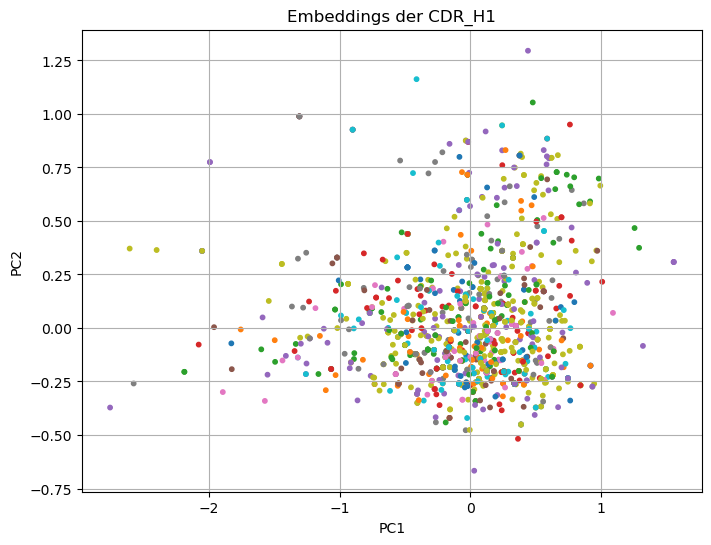

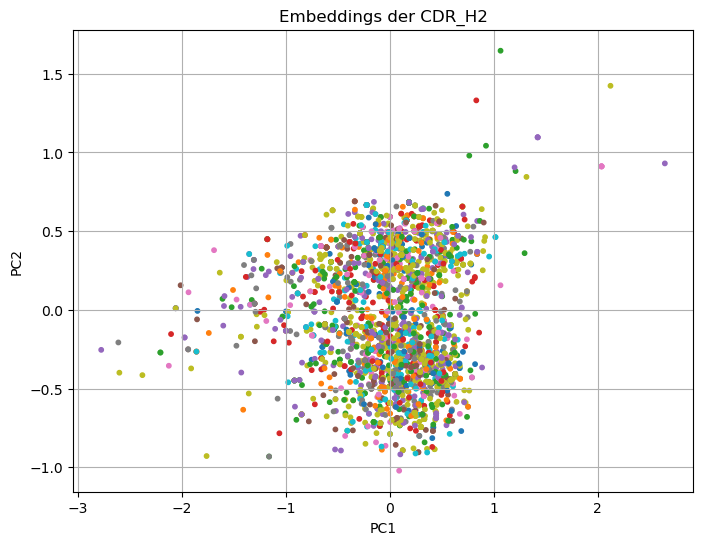

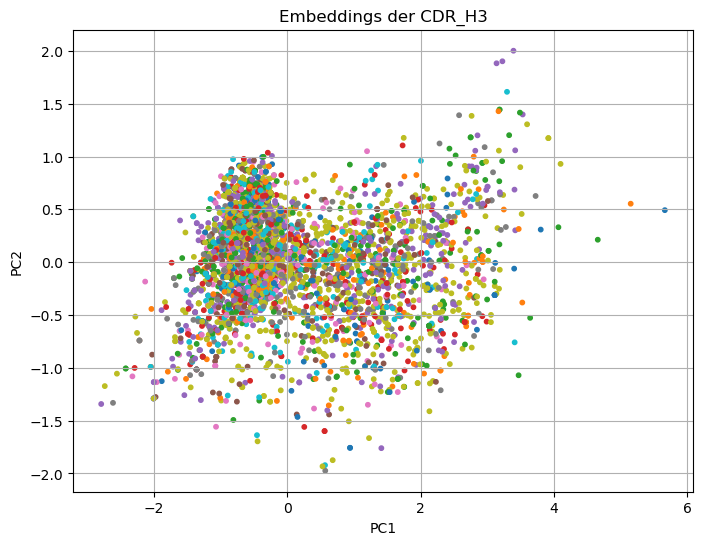

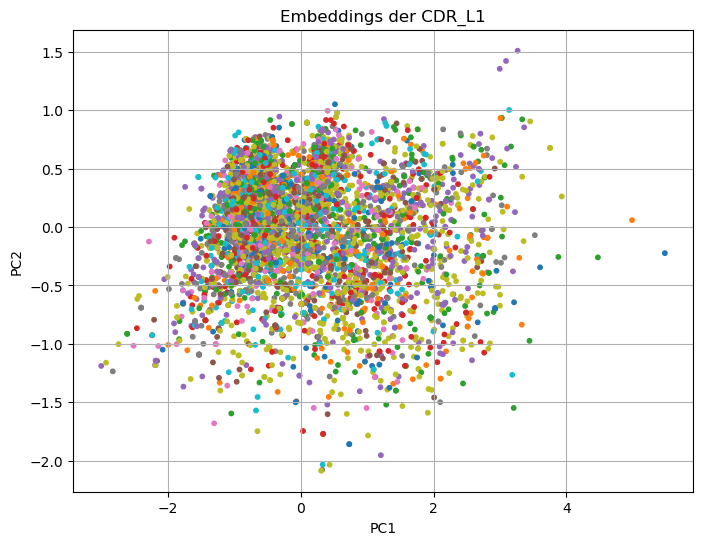

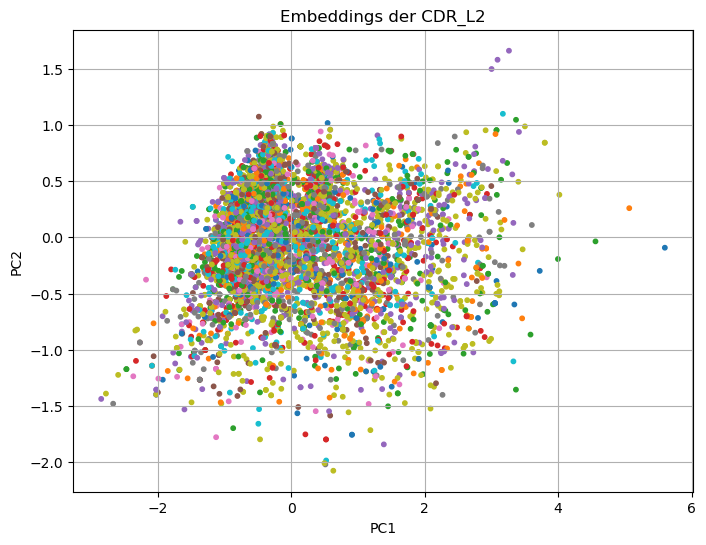

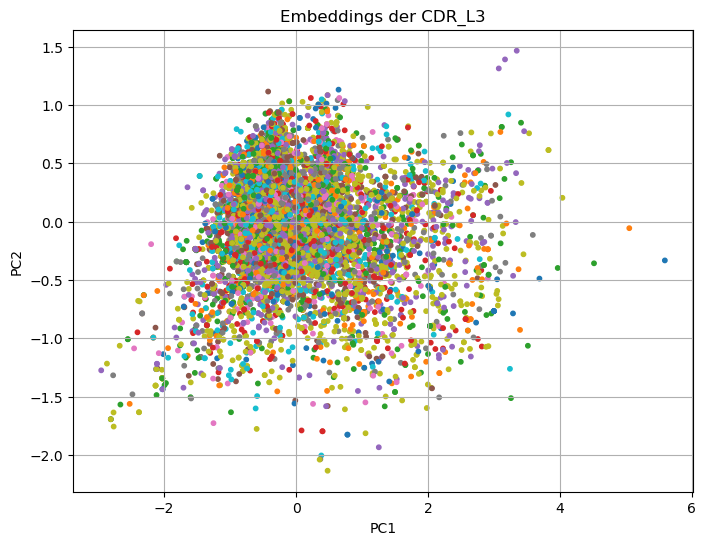

In [5]:
fs_rows = []
for region in regions:
    for i, df_row in df.iterrows():
        pdb = df_row["pdb"]
        antigen_name = df_row["antigen_name"]
        antigen_species = df_row["antigen_species"]
    
        embedding_as_arr = np.load(f"data/embeddings/{pdb}/{pdb}_{region}.npy")
        #embedding_as_vec = embedding_as_arr.mean(axis=0)
        embedding_as_vec = PCA(n_components=1).fit_transform(embedding_as_arr.T).flatten()

        fs_row = [pdb] + [antigen_name] + [antigen_species] + embedding_as_vec.tolist()
        fs_rows.append(fs_row)
    feature_space = pd.DataFrame(fs_rows, columns = ["pdb"] + ["antigen_name"] + ["antigen_species"] + [f"{i}" for i in range(embedding_as_vec.shape[0])])
    # Speichert die Embedding-Vektoren in einem DataFrame, der später für KMeans genutzt wird

    X = feature_space.drop(columns=["pdb"] + ["antigen_name"] + ["antigen_species"]).values
    X_2d = PCA(n_components=2).fit_transform(X)
    plt.figure(figsize=(8, 6))
    plt.scatter(X_2d[:, 0], X_2d[:, 1], c=pd.Categorical(feature_space["antigen_name"]).codes, cmap='tab10', s=10)
    plt.title(f"Embeddings der {region}")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True)
    plt.show()

    #labels = KMeans(n_clusters=10, random_state=42).fit_predict(X) (für KMeans-Clustering)


In [6]:
'''# Alternative: Darstellung der Embeddings über Hausdorff-Distanz und Multidimensional Scaling
from scipy.spatial.distance import directed_hausdorff
from sklearn.manifold import MDS

subset_df = df.sample(300, random_state=42)


for region in regions:
    alle_embeddings = []
    labels = []
    for i, df_row in subset_df.iterrows():
        pdb = df_row["pdb"]
        antigen_name = df_row["antigen_name"]
        #antigen_species = df_row["antigen_species"]
        embedding_as_arr = np.load(f"data/embeddings/{pdb}/{pdb}_{region}.npy")
        alle_embeddings.append(embedding_as_arr)
        labels.append(antigen_name)
    n = len(alle_embeddings)
    dist_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            dist = directed_hausdorff(alle_embeddings[i], alle_embeddings[j])[0]
            dist_matrix[i, j] = dist
            dist_matrix[j, i] = dist
    mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
    coords = mds.fit_transform(dist_matrix)

    label_codes = pd.Categorical(labels).codes
    label_categories = pd.Categorical(labels).categories
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(coords[:, 0], coords[:, 1], c=label_codes, cmap='tab10', s=20)
    plt.legend(handles=scatter.legend_elements()[0], labels=list(label_categories), title="Antigen", loc="best")
    plt.title(f"Embeddings der {region} (Hausdorff)")
    plt.grid(True)
    plt.show()'''

'# Alternative: Darstellung der Embeddings über Hausdorff-Distanz und Multidimensional Scaling\nfrom scipy.spatial.distance import directed_hausdorff\nfrom sklearn.manifold import MDS\n\nsubset_df = df.sample(300, random_state=42)\n\n\nfor region in regions:\n    alle_embeddings = []\n    labels = []\n    for i, df_row in subset_df.iterrows():\n        pdb = df_row["pdb"]\n        antigen_name = df_row["antigen_name"]\n        #antigen_species = df_row["antigen_species"]\n        embedding_as_arr = np.load(f"data/embeddings/{pdb}/{pdb}_{region}.npy")\n        alle_embeddings.append(embedding_as_arr)\n        labels.append(antigen_name)\n    n = len(alle_embeddings)\n    dist_matrix = np.zeros((n, n))\n    for i in range(n):\n        for j in range(i + 1, n):\n            dist = directed_hausdorff(alle_embeddings[i], alle_embeddings[j])[0]\n            dist_matrix[i, j] = dist\n            dist_matrix[j, i] = dist\n    mds = MDS(n_components=2, dissimilarity=\'precomputed\', random_stat

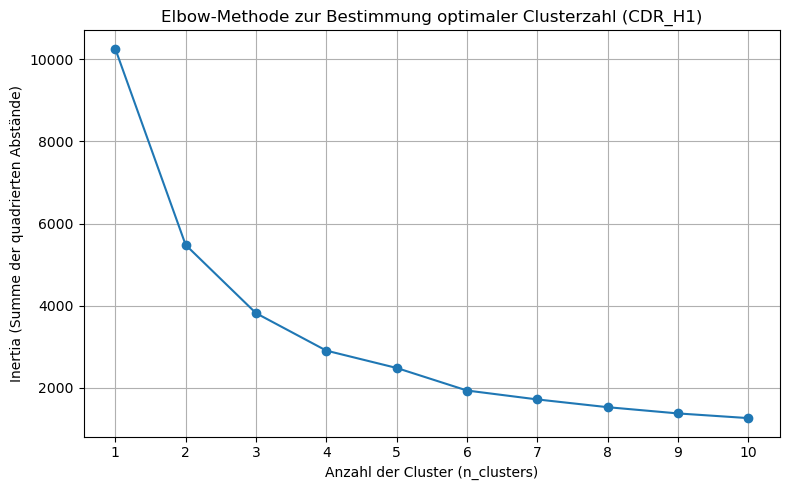

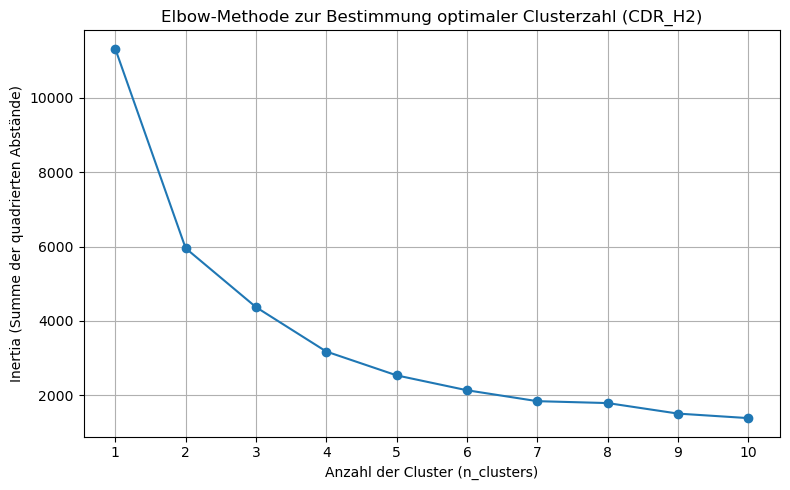

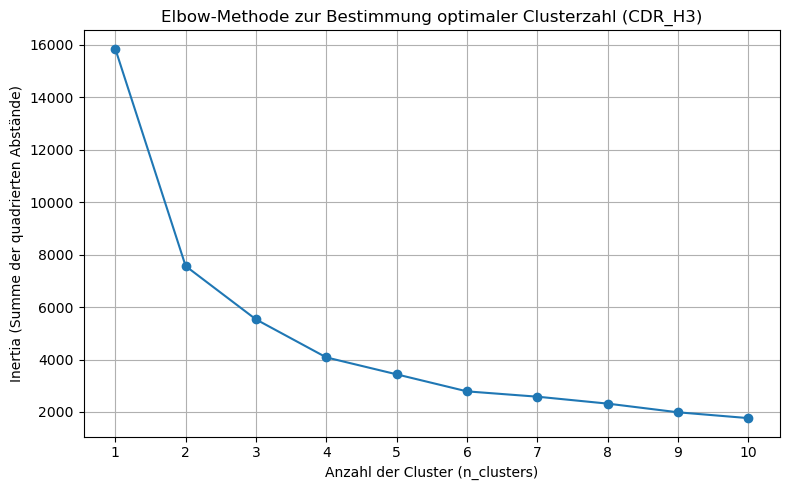

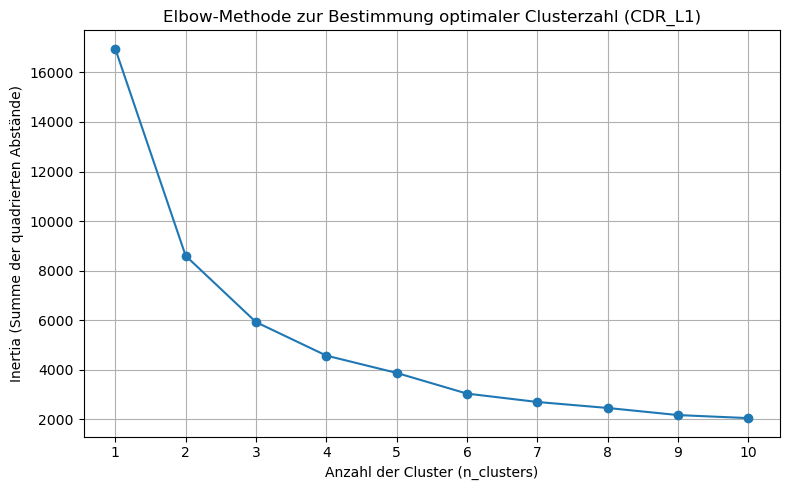

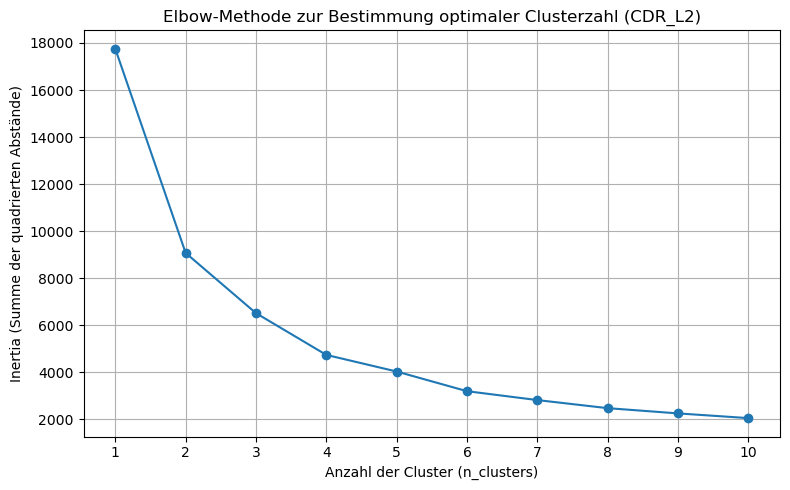

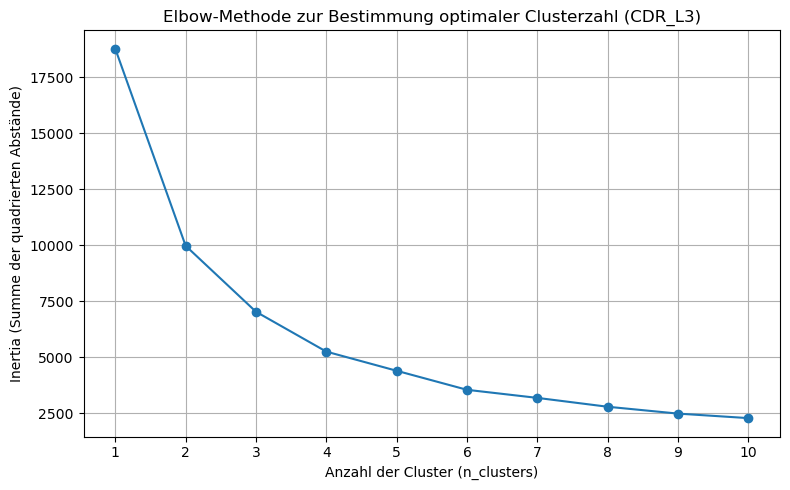

In [ ]:
#elbow method 
for region in regions:
    for i, df_row in df.iterrows():
        pdb = df_row["pdb"]
        antigen_name = df_row["antigen_name"]
        antigen_species = df_row["antigen_species"]
    
        embedding_as_arr = np.load(f"data/embeddings/{pdb}/{pdb}_{region}.npy")
        #embedding_as_vec = embedding_as_arr.mean(axis=0)
        embedding_as_vec = PCA(n_components=1).fit_transform(embedding_as_arr.T).flatten()

        fs_row = [pdb] + [antigen_name] + [antigen_species] + embedding_as_vec.tolist()
        fs_rows.append(fs_row)
    feature_space = pd.DataFrame(fs_rows, columns = ["pdb"] + ["antigen_name"] + ["antigen_species"] + [f"{i}" for i in range(embedding_as_vec.shape[0])])
    # Speichert die Embedding-Vektoren in einem DataFrame, der später für KMeans genutzt wird
    X = feature_space.drop(columns=["pdb", "antigen_name", "antigen_species"])
    coords = PCA(n_components=2).fit_transform(X)

    #inertia => Summe der quadrierten Abstände der Punkte zum jeweiligen Cluster-Zentrum => je kleiner, desto besser
    from sklearn.cluster import KMeans
    import matplotlib.pyplot as plt

    # Range of cluster numbers to try
    cluster_range = range(1, 11)  # Teste 1-10 Cluster

    # Hier Inertia-Werte speichern, [] für liste
    inertia_values = []

    # Berechne KMeans für jede Cluster-Anzahl
    for n_clusters in cluster_range:
        kmeans = KMeans(n_clusters=n_clusters, random_state=42)
        kmeans.fit(coords)  # fit passt daten an modell an => kmeans bekommt daten (coords der antikörper punkte) und initialisiert Cluster Zentren und macht dann iterative optimierung 
        # also weist punkte dem nächsten cluster zentrum zu, bei den gebildeten cluster wenn neue zentren berechnet und die punkte werden neu zugeordnet
        inertia_values.append(kmeans.inertia_)

    # Plot der Elbow-Kurve
    plt.figure(figsize=(8, 5))
    plt.plot(cluster_range, inertia_values, marker='o')
    plt.xlabel('Anzahl der Cluster (n_clusters)')
    plt.ylabel('Inertia (Summe der quadrierten Abstände)')
    plt.title(f'Elbow-Methode zur Bestimmung optimaler Clusterzahl ({region})')
    plt.xticks(cluster_range) #x achse werden dann anzhal cluster gezeigt
    plt.grid(True) #gitternetzlinien im plot
    plt.tight_layout()
    plt.show()


CDR_H1
        pdb                                       antigen_name  \
0      9ds2   hemagglutinin ha2 chain | hemagglutinin ha1 chai   
1      8uzp                                    stem_mimetic_01   
2      8veb                                      hemagglutinin   
3      8ved                                      hemagglutinin   
4      8vef                                      hemagglutinin   
...     ...                                                ...   
41170  7n3d                                      nucleoprotein   
41171  4od2  tumor necrosis factor receptor superfamily mem...   
41172  3q1s                                     interleukin-22   
41173  5sy8                       10e8 epitope scaffold t117v2   
41174  4ps4                                     interleukin-13   

                                       antigen_species         0         1  \
0                influenza a virus | influenza a virus  0.023762  0.141505   
1                                         mu

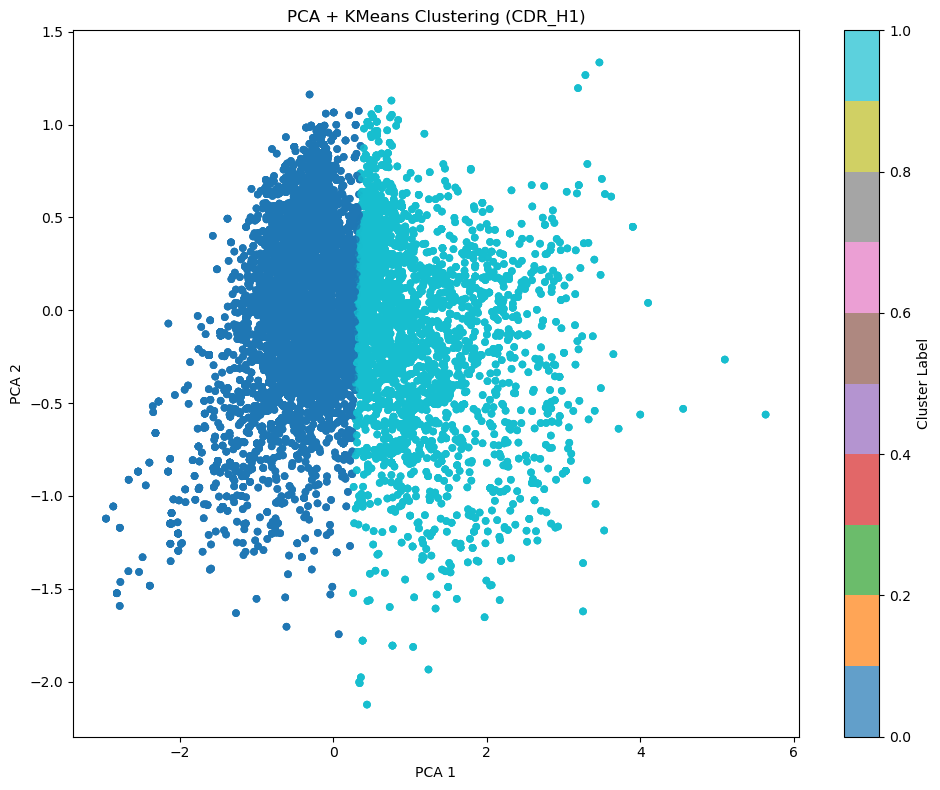


 Antigen Häufigkeiten pro Cluster für CDR_H1 

Cluster 0:
  spike protein s1: 191x
  spike glycoprotein: 187x
  hemagglutinin: 49x
  neuraminidase: 24x
  surface glycoprotein: 22x
  envelope glycoprotein gp160: 19x
  clade a/e 93th057 hiv-1 gp120 core: 18x
  envelope glycoprotein e2: 15x
  fusion glycoprotein f0: 15x
  gametocyte surface protein p230: 15x
  hemagglutinin | hemagglutinin: 14x
  programmed cell death protein 1: 14x
  unknown: 13x
  hemagglutinin ha2 chain | hemagglutinin ha1 chain: 12x
  envelope glycoprotein gp120: 11x
  receptor tyrosine-protein kinase erbb-2: 9x
  envelope glycoprotein b: 9x
  25 kda ookinete surface antigen: 9x
  circumsporozoite protein: 9x
  hemagglutinin ha1 chain: 8x
  cytotoxic t-lymphocyte protein 4: 7x
  leukocyte surface antigen cd47: 7x
  tyrosine-protein phosphatase non-receptor type substrate 1: 7x
  interleukin-17a: 7x
  nucleoprotein: 7x
  reticulocyte binding protein 2b: 7x
  gametocyte surface protein p45/48: 6x
  outer surface protei

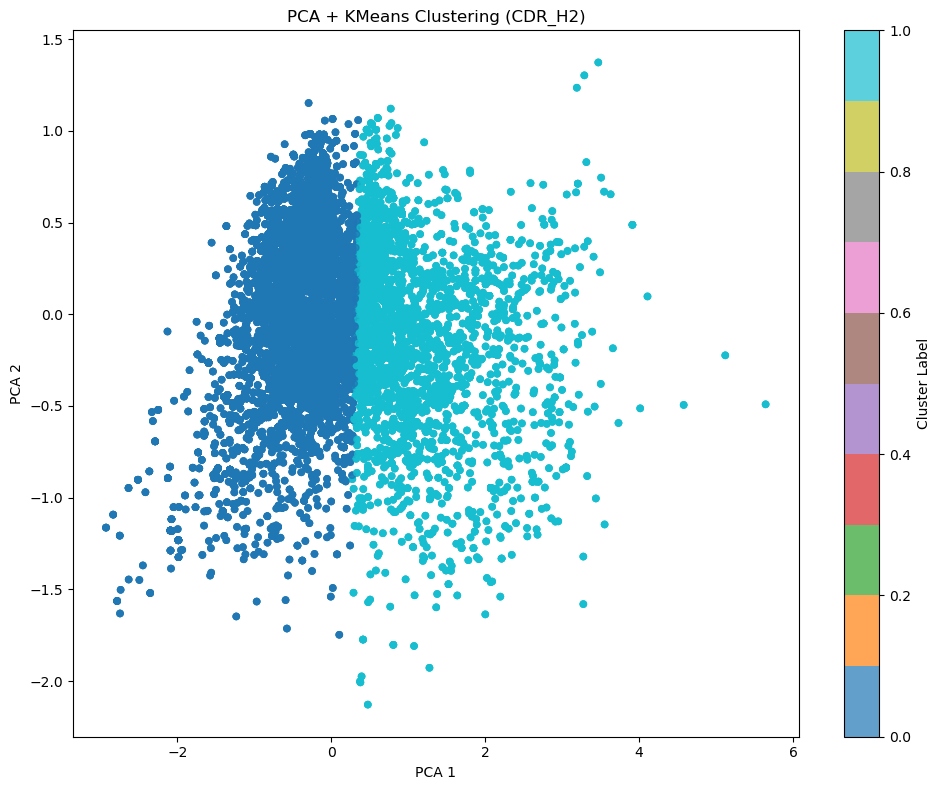


 Antigen Häufigkeiten pro Cluster für CDR_H2 

Cluster 0:
  spike protein s1: 191x
  spike glycoprotein: 187x
  hemagglutinin: 49x
  neuraminidase: 24x
  surface glycoprotein: 22x
  envelope glycoprotein gp160: 19x
  clade a/e 93th057 hiv-1 gp120 core: 18x
  envelope glycoprotein e2: 15x
  fusion glycoprotein f0: 15x
  gametocyte surface protein p230: 15x
  hemagglutinin | hemagglutinin: 14x
  programmed cell death protein 1: 14x
  unknown: 13x
  hemagglutinin ha2 chain | hemagglutinin ha1 chain: 12x
  envelope glycoprotein gp120: 11x
  receptor tyrosine-protein kinase erbb-2: 9x
  envelope glycoprotein b: 9x
  25 kda ookinete surface antigen: 9x
  circumsporozoite protein: 9x
  hemagglutinin ha1 chain: 8x
  cytotoxic t-lymphocyte protein 4: 7x
  leukocyte surface antigen cd47: 7x
  tyrosine-protein phosphatase non-receptor type substrate 1: 7x
  interleukin-17a: 7x
  nucleoprotein: 7x
  reticulocyte binding protein 2b: 7x
  gametocyte surface protein p45/48: 6x
  outer surface protei

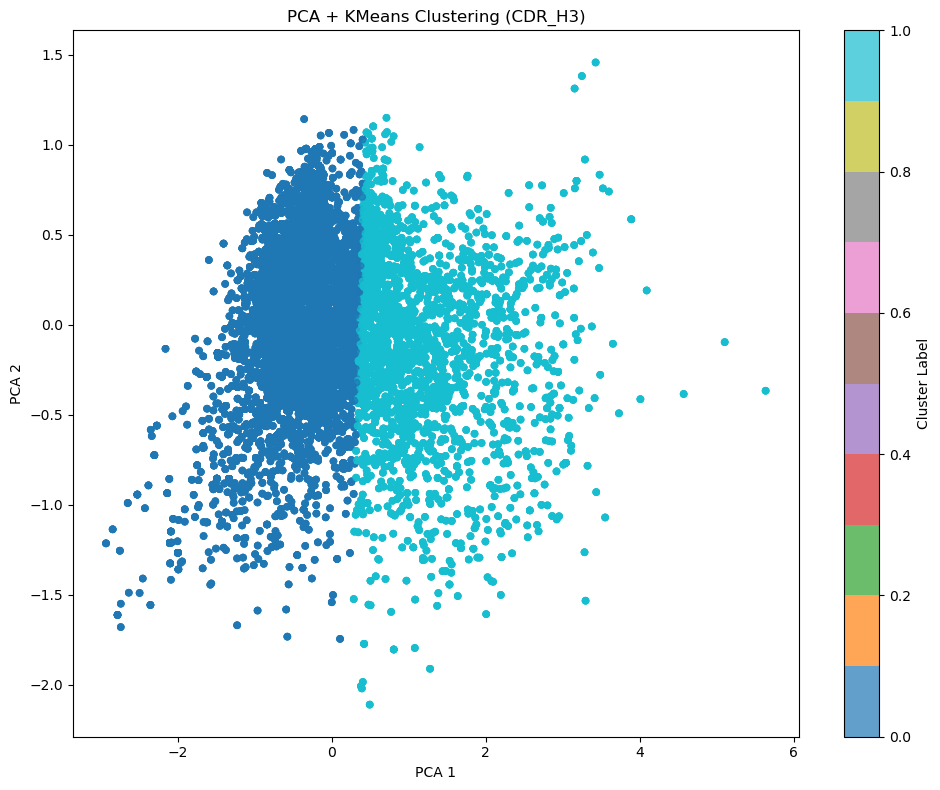


 Antigen Häufigkeiten pro Cluster für CDR_H3 

Cluster 0:
  spike protein s1: 191x
  spike glycoprotein: 188x
  hemagglutinin: 49x
  neuraminidase: 25x
  surface glycoprotein: 22x
  envelope glycoprotein gp160: 19x
  clade a/e 93th057 hiv-1 gp120 core: 18x
  envelope glycoprotein e2: 15x
  fusion glycoprotein f0: 15x
  gametocyte surface protein p230: 15x
  hemagglutinin | hemagglutinin: 14x
  programmed cell death protein 1: 14x
  unknown: 13x
  hemagglutinin ha2 chain | hemagglutinin ha1 chain: 12x
  envelope glycoprotein gp120: 11x
  receptor tyrosine-protein kinase erbb-2: 9x
  envelope glycoprotein b: 9x
  25 kda ookinete surface antigen: 9x
  circumsporozoite protein: 9x
  hemagglutinin ha1 chain: 8x
  cytotoxic t-lymphocyte protein 4: 7x
  leukocyte surface antigen cd47: 7x
  tyrosine-protein phosphatase non-receptor type substrate 1: 7x
  interleukin-17a: 7x
  nucleoprotein: 7x
  reticulocyte binding protein 2b: 7x
  gametocyte surface protein p45/48: 6x
  outer surface protei

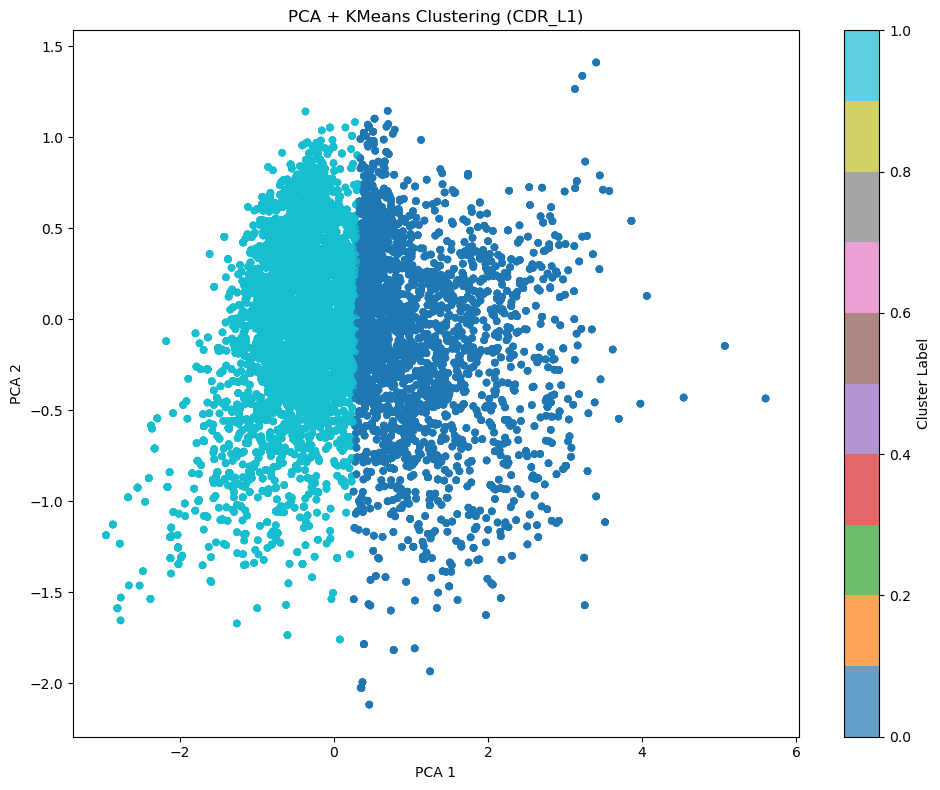


 Antigen Häufigkeiten pro Cluster für CDR_L1 

Cluster 0:
  hemagglutinin: 4x
  spike protein s1: 2x
  envelope glycoprotein gp120: 2x
  h1h5 ha: 1x
  envelope glycoprotein e: 1x
  outer surface protein c: 1x
  neuraminidase: 1x
  spike glycoprotein | spike glycoprotein: 1x
  coagulation factor viii: 1x
  e2 glycoprotein: 1x
  hemagglutinin ha1 chain: 1x
  genome polyprotein: 1x
  envelope glycoprotein gp160,envelope glycoprotein gp160: 1x
  fusion glycoprotein f0: 1x
  epidermal growth factor receptor: 1x
  spike glycoprotein: 1x
  imv membrane protein: 1x
  gp120: 1x
  hemagglutinin ha1: 1x

Cluster 1:
  spike protein s1: 191x
  spike glycoprotein: 187x
  hemagglutinin: 49x
  neuraminidase: 24x
  surface glycoprotein: 22x
  envelope glycoprotein gp160: 19x
  clade a/e 93th057 hiv-1 gp120 core: 18x
  envelope glycoprotein e2: 15x
  fusion glycoprotein f0: 15x
  gametocyte surface protein p230: 15x
  hemagglutinin | hemagglutinin: 14x
  programmed cell death protein 1: 14x
  unknown: 

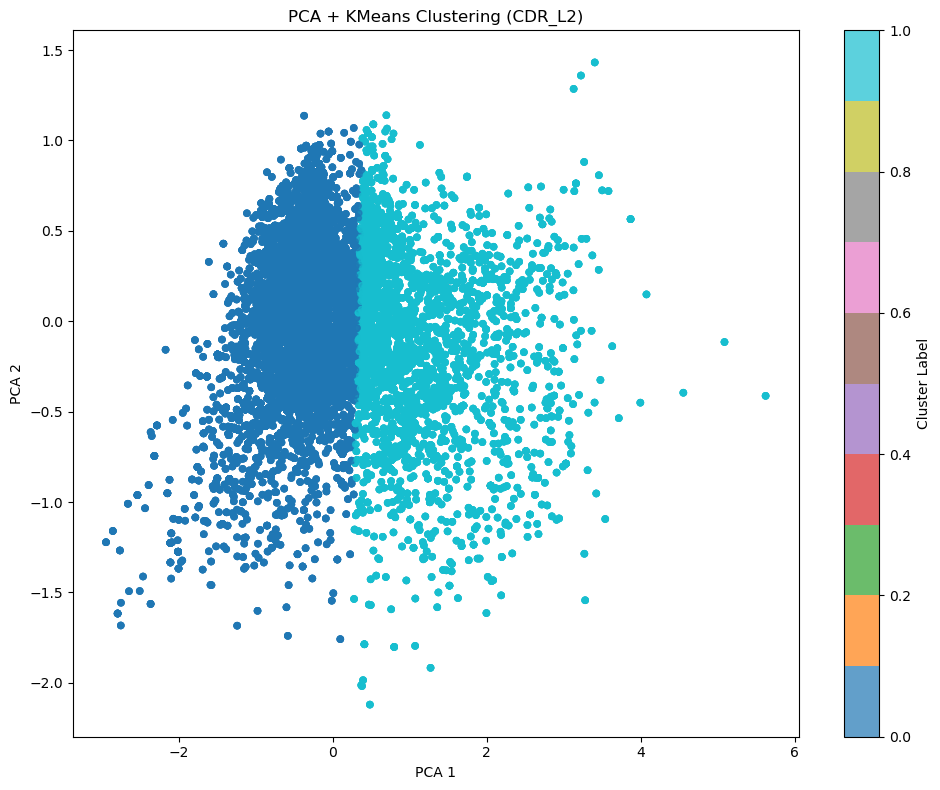


 Antigen Häufigkeiten pro Cluster für CDR_L2 

Cluster 0:
  spike protein s1: 191x
  spike glycoprotein: 188x
  hemagglutinin: 49x
  neuraminidase: 24x
  surface glycoprotein: 22x
  envelope glycoprotein gp160: 19x
  clade a/e 93th057 hiv-1 gp120 core: 18x
  envelope glycoprotein e2: 15x
  fusion glycoprotein f0: 15x
  gametocyte surface protein p230: 15x
  hemagglutinin | hemagglutinin: 14x
  programmed cell death protein 1: 14x
  unknown: 13x
  hemagglutinin ha2 chain | hemagglutinin ha1 chain: 12x
  envelope glycoprotein gp120: 11x
  receptor tyrosine-protein kinase erbb-2: 9x
  envelope glycoprotein b: 9x
  25 kda ookinete surface antigen: 9x
  circumsporozoite protein: 9x
  hemagglutinin ha1 chain: 8x
  cytotoxic t-lymphocyte protein 4: 7x
  leukocyte surface antigen cd47: 7x
  tyrosine-protein phosphatase non-receptor type substrate 1: 7x
  interleukin-17a: 7x
  nucleoprotein: 7x
  reticulocyte binding protein 2b: 7x
  gametocyte surface protein p45/48: 6x
  outer surface protei

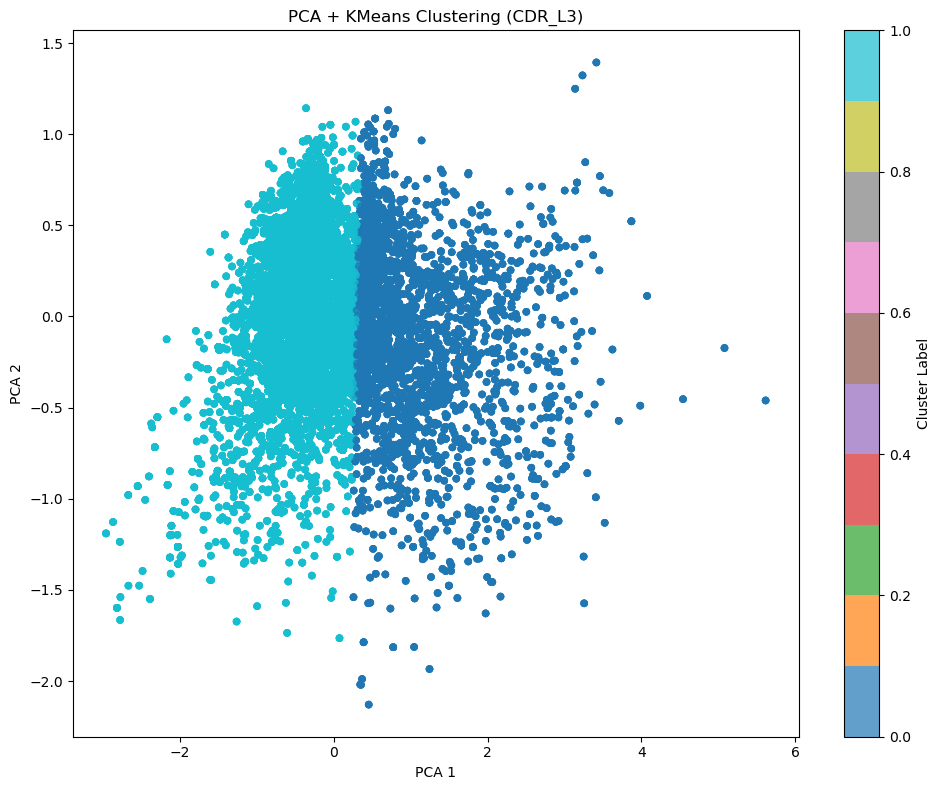


 Antigen Häufigkeiten pro Cluster für CDR_L3 

Cluster 0:
  hemagglutinin: 4x
  spike protein s1: 2x
  envelope glycoprotein gp120: 2x
  h1h5 ha: 1x
  envelope glycoprotein e: 1x
  outer surface protein c: 1x
  neuraminidase: 1x
  spike glycoprotein | spike glycoprotein: 1x
  coagulation factor viii: 1x
  e2 glycoprotein: 1x
  hemagglutinin ha1 chain: 1x
  genome polyprotein: 1x
  envelope glycoprotein gp160,envelope glycoprotein gp160: 1x
  fusion glycoprotein f0: 1x
  epidermal growth factor receptor: 1x
  spike glycoprotein: 1x
  imv membrane protein: 1x
  duffy binding surface protein region ii: 1x
  gp120: 1x
  hemagglutinin ha1: 1x

Cluster 1:
  spike protein s1: 191x
  spike glycoprotein: 187x
  hemagglutinin: 49x
  neuraminidase: 24x
  surface glycoprotein: 22x
  envelope glycoprotein gp160: 19x
  clade a/e 93th057 hiv-1 gp120 core: 18x
  envelope glycoprotein e2: 15x
  fusion glycoprotein f0: 15x
  gametocyte surface protein p230: 15x
  hemagglutinin | hemagglutinin: 14x
  pr

In [26]:
# Clustering auf basis der PCA
#kmeans mit 2 => laut elbow method am sinnvollsten

from sklearn.cluster import KMeans
from collections import Counter #Counter => zum Zählen der Antigen-Namen pro Cluster
antigen_labels = df["antigen_name"].tolist()
for region in regions:
    for i, df_row in df.iterrows():
        pdb = df_row["pdb"]
        antigen_name = df_row["antigen_name"]
        antigen_species = df_row["antigen_species"]
    
        embedding_as_arr = np.load(f"data/embeddings/{pdb}/{pdb}_{region}.npy")
        #embedding_as_vec = embedding_as_arr.mean(axis=0)
        embedding_as_vec = PCA(n_components=1).fit_transform(embedding_as_arr.T).flatten()

        fs_row = [pdb] + [antigen_name] + [antigen_species] + embedding_as_vec.tolist()
        fs_rows.append(fs_row)
    feature_space = pd.DataFrame(fs_rows, columns = ["pdb"] + ["antigen_name"] + ["antigen_species"] + [f"{i}" for i in range(embedding_as_vec.shape[0])])
    # Speichert die Embedding-Vektoren in einem DataFrame, der später für KMeans genutzt wird
    X = feature_space.drop(columns=["pdb", "antigen_name", "antigen_species"])
    coords = PCA(n_components=2).fit_transform(X)
    print(feature_space)

    # n_clusters frei wählbar
    kmeans = KMeans(n_clusters=2, random_state=42) #random state wichtig damit auch bei jeden durchlauf gleiche cluster entstehen
    cluster_labels = kmeans.fit_predict(coords) #fit predict führt clustering im 2d pca space durch

    # Plot => Cluster einfärben
    plt.figure(figsize=(10, 8))
    plt.scatter(coords[:, 0], coords[:, 1], c=cluster_labels, cmap='tab10', s=20, alpha=0.7) #c=cöuster labels färbt die punkte nach cluster; tab10 => 10 farben, alpha => tranparenz damit überlappungen sichtbar, s => punktgröße
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.title(f"PCA + KMeans Clustering ({region})")
    plt.colorbar(label='Cluster Label')
    plt.tight_layout()
    plt.show()
        

    #antigen names häufigkeiten in den clustern

    # Erzeuge Mapping: cluster_label → liste von antigen names
    # Dictionary ({} => speichert key => value paare) bauen, in dem für jedes Cluster die Liste der zugehörigen Antigen-Namen gespeichert wird
    cluster_antigen_mapping = {}

    # Gehe alle Punkte durch (alle Antikörper im PCA/Feature-Space)
    # → zip(cluster_labels, antigen_labels) gibt für jeden Punkt: cluster_label: die Cluster-Nummer (z.B. 0, 1, 2, ...) & antigen_name: der Antigen-Name dieses Antikörpers
    for cluster_label, antigen_name in zip(cluster_labels, antigen_labels):

        # Wenn dieses Cluster-Label noch nicht im Dictionary ist => leeres Array initialisieren
        if cluster_label not in cluster_antigen_mapping:
            cluster_antigen_mapping[cluster_label] = []

        # Füge den Antigen-Namen zur Liste für dieses Cluster hinzu
        cluster_antigen_mapping[cluster_label].append(antigen_name)

    #jetzt haben wir für jedes cluster eine liste mit den vorkommenden antigen names

    #für häufigkeiten:
    #header damit klar für welche cdr region
    print(f"\n Antigen Häufigkeiten pro Cluster für {region} ")
    # alle Cluster-Labels sortiert durchgehen
    for cluster_label in sorted(cluster_antigen_mapping.keys()):

        # Drucke Cluster-Header
        print(f"\nCluster {cluster_label}:")

        # wie oft jeder Antigen-Name in diesem Cluster vorkommt
        counter = Counter(cluster_antigen_mapping[cluster_label])

        # Antigen-Namen + Anzahl sortiert nach Häufigkeit aus geben
        for antigen, count in counter.most_common():
            print(f"  {antigen}: {count}x")

In [ ]:
#Proportionstest => testen, ob die Antigen-Namen systematisch unterschiedlich auf die Cluster verteilt sind
from sklearn.cluster import KMeans
from scipy.stats import chi2_contingency
import pandas as pd

#nullhypothese (H0): Verteilung der Antigen-Namen auf die Cluster ist zufällig
#H1: Verteilung der Antigen-Namen auf die Cluster ist nicht zufällig

for CDR_region in ["CDR_H1", "CDR_H2", "CDR_H3", "CDR_L1", "CDR_L2", "CDR_L3"]:

    # Kontingenztabelle (Antigen x Cluster) erzeugen

    # automatische Zählung und erstellen von dataframe über crosstab
    contingency_table = pd.crosstab(pd.Series(antigen_labels, name='Antigen'), pd.Series(cluster_labels, name='Cluster'))

    #kontingenztabelle printen
    print(f"\n Kontingenztabelle für {CDR_region}")
    print(contingency_table)

    #chi-quadrat-test
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    #chi2=maß für wie stark die beobachteten häufigkeiten von den erwarteten abweichen (je größer, desto größer abweichung)
    #p-Wert=Wahrscheinlichkeit, bei zufälliger Verteilung eine Abweichung mindestens so groß wie chi2 zu beobachten
    #dof=degrees of freedom (#zeilen-1 * #spalten-1)
    #expected=tabelle mit erwarteten häufigkeiten unter nullhypothese

    #print ergebnisse
    print(f"\n Chi-Quadrat-Test Ergebnis für {CDR_region}")
    print(f"Chi2-Wert: {chi2:.4f}") #4f für 4 nachkommSTELLEN
    print(f"p-Wert:    {p:.4e}")  # 4e für exponentielle darstellung mit 4 nachkommastellen
    print(f"Freiheitsgrade: {dof}")

    #print die expected werte zum vergleich
    expected_df = pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns)
    print(f"\nErwartete Häufigkeiten (unter Nullhypothese):")
    print(expected_df.round(2)) #auf 2 nachkommastellen runden

    #die tatsache dass die antigen_name häufigkeiten sehr unterschiedlich sind wird hier automatisch berücksichtigt: 
    #expected-Array wird aus den Randhäufigkeiten berechnet => randhäufigkeiten für antigen =  Summe pro Zeile => wie oft kommt jedes Antigen insgesamt im ganzen Datensatz vor?
    #randhäufigkeiten für cluster=Summe pro Spalte => wie groß ist jedes Cluster insgesamt?

    #wenn p < 0.05 => signifikant also die verteilung unterschiedet sich signifikant von zufall => N0 hypothese muss verworfen werden denn die unterschiede in der verteilung sind nicht durch zufall zu erklären
